# Resonance Engineering of Floquet condensate: QOC approach


We are interested by the following quantum optimal control problem (QOCP) 

$$
\min ~~ J(\psi,u)  = \frac{1}{2}\left(1 - |\langle \psi_d, \psi(T)\rangle|^2\right)  + \frac{\alpha}{2} \int_0^T |u(t)|^2 \, d t \\
\text{subject to} ~~~~ i \partial_t \psi = \left(H_0 + u(t)H_1) \right) \psi, \quad \psi(x,0) = \psi^0(x)
$$

Where  

$$
H_0 = -D_0 + diag(V(x)), ~~~ V(x) = V_0\sin^2\left(\frac{\pi x}{d}\right) + \frac{m\omega_T^2 x^2}{2} \\ 
H_1 = diag(V_{\mathrm{ext}}(x)), ~~~ V_{\mathrm{ext}}(x) = \left(\frac{m\omega_T^2 x^2}{2} \sin(\omega_D t + \phi) \right) u(t)
$$

$D_0$ denoted the discret Laplacian, $x = (x_1,\ldots,x_M)$ is a state discretization.

$\psi_d$ is the solution of the system

$$
i \partial_t \psi = \left(H_0 + f(t)H_1) \right) \psi, \quad \psi(x,0) = Id
$$

with $f(t) = \sin^2(t)$

$$\psi_0 = e^{-\frac{(x-x_0)^2}{2σ^2}}$$

$V_0, \sigma, \omega_t, \omega_d, \phi$ being constants defining in the following.

In [2]:
import numpy as np
import scipy as sp
from scipy.sparse.linalg import expm
from numpy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import expsolve.fourier as fe
import pickle
import time
import pandas as pd

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType (acceptable)
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False  # avoid LaTeX->Type3 in figures



SMALL_SIZE  = 13
MEDIUM_SIZE = 17
BIGGER_SIZE = 19

plt.rc('font',  size=BIGGER_SIZE)         # controls default text sizes
plt.rc('axes',  titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes',  labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)     # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)     # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)     # legend fontsize

## Quantum optimal control problem: simple example in the linear case

In [3]:
## Patial grid 
d   = 50;
α   = 0.1;
σ   = 2.23;    
ϕ   = 0.0;
k0  = 0.0;               
K0  = 0.00032;
V0  = 10;
J   = 0.027;             
ωd  = 0.0024
Ohm = K0; 
Jay = ωd;
ω   = 2*Ohm*35;
ϕ   = 0; 
L   = 50; 
n   = 200;
m   = np.ones((n-1));
xr  = [-L, L];           
x   = fe.grid1d(n, xr)

# defining time variable (one-period)
N = 50; 
T = 2.*np.pi/ωd; t0 = 0.0
h = T/N;
tspan = np.linspace(0,T,N)
tspan2 = np.linspace(T,0,N)

f = lambda t: np.sin(t)**2;                                            # Varying Driving Strength


In [4]:
def updiag(m):
    matrix = np.zeros((len(m)+1, len(m)+1))
    for i in range(len(m)):
        matrix[i, i+1] = m[i];
    return matrix

def lodiag(m):
    matrix = np.zeros((len(m)+1, len(m)+1))
    for i in range(1, len(m)+1):
        matrix[i, i-1] = m[i-1];
    return matrix

In [5]:
# Unperturbed Hamiltonian
H0   = (Ohm)*np.diag(x**2)- ωd*(updiag(np.array(m)) + lodiag(np.array(m))) ;

# control Hamiltonian
H1 = lambda t: (Ohm)*np.sin(ω*t + ϕ)*np.diag(x**2)


# Matrix function A for Cayley method
A0 = lambda t, u: -1j*H0 - 1j*u*H1(t)
x1 = 1/2 - np.sqrt(3)/6
x2 = 1/2 + np.sqrt(3)/6
A1 = lambda t,h,u: h*(A0(t + x1*h, u) + A0(t + x2*h, u))/2
A2 = lambda t,h,u: h*(A0(t + x2*h, u) - A0(t + x1*h, u))*(np.sqrt(3)/2)



In [6]:
# Cayley commutator scheme

def commutator(A,B):
    return A@B - B@A


def Cayleystep(t, h, y, u): 
    x1 = 1/2 - np.sqrt(3)/6
    x2 = 1/2 + np.sqrt(3)/6 
    A      = A1(t, h, u)
    B      = A2(t, h, u)
    Omega  = A - 1/6*commutator(A, B) - (1/12)*A@A@A
    Cayley = (np.identity(np.size(y)) + Omega/2)@y
    yout   = np.linalg.solve(np.identity(np.size(y)) - Omega/2, Cayley)
    return yout


def runCayleyMagnus4(T, M, y0, U):
    y      = 1j*np.zeros((M+1,np.size(y0)))
    y[0,:] = y0
    for n in range(M):
        t = n*T/M
        h = T/M
        y[n+1,:] = Cayleystep(t, h, y[n,:], U[n])
    return y

In [7]:
def Cayleyfreestep(t, h, y, u):
    coef = 2**(1/3)/3 + 2**(2/3)/6 + 2/3
    a11  = coef;  a12 =-coef**2 + coef;
    a22  = 0.0;   a21 = 1 - 2*coef;
    a31  = a11;   a32 =-a12; 
    A        = A1(t, h, u)
    B        = A2(t, h, u)
    Omega1   = a11*A + a12*B 
    Omega2   = a21*A + a22*B 
    Omega3   = a31*A + a32*B
    y1       = (np.identity(np.size(y)) + Omega3/2)@y
    Cayley3  = np.linalg.solve(np.identity(np.size(y)) - Omega3/2, y1)
    y1       = (np.identity(np.size(y)) + Omega2/2).dot(Cayley3)
    Cayley2  = np.linalg.solve(np.identity(np.size(y)) - Omega2/2, y1)
    y1       = (np.identity(np.size(y)) + Omega1/2).dot(Cayley2)
    Cayley1  = np.linalg.solve(np.identity(np.size(y)) - Omega1/2, y1)
    return Cayley1


def runCFCayley4(T, M, y0, U):
    y    = 1j*np.zeros((M+1,np.size(y0)))
    y[0,:] = y0
    for n in range(M):
        t = n*T/M
        h = T/M 
        y[n+1,:] = Cayleyfreestep(t,h,y[n,:], U[n])
    return y

In [8]:
def Expcommfree(t, h, y, u):
    A      = A1(t, h, u)
    B      = A2(t, h, u)
    Omega1 = A/2 + B/3                                                       
    Omega2 = A/2 - B/3  
    Comfre = sp.linalg.expm(Omega1)@sp.linalg.expm(Omega2)
    yout   = Comfre
    return yout@y

def runExpcommfree(T, M, y0, U):
    y    = 1j*np.zeros((M+1,np.size(y0)))
    y[0,:] = y0
    h    = T/M
    for n in range(M):
        t = n*T/M
        y[n+1,:] = Expcommfree(t,h,y[n,:], U[n])
    return y

def runExpcommfreeb(T, M, y0, U):
    y    = 1j*np.zeros((M+1,np.size(y0)))
    y[0,:] = y0
    h    = T/M
    for n in range(M):
        t = T - n*T/M
        y[n+1,:] = Expcommfree(t,h,y[n,:], U[-n-1])
    return y

In [9]:
## optimal control step
ustep = lambda t, ψ, χ: ((1/α)*np.dot((H1(t)).dot(ψ),χ)).imag

## optimal control function
def ufun(t, ψ, χ):
    u    = np.zeros(np.size(t))
    for i in range(len(t)):
        u[i] = ustep(t[i], ψ[i,:], χ[i,:])
    return u

## Final adjoint
χT = lambda ψ, ψd: np.dot(ψd, ψ)*ψd

## Cost function
def J(ψ, u):
    J = 1/2*(1 - np.abs(fe.l2inner(ψd, ψ, xr))**2);
    for n in range(len(tspan)):
        J = J - (α/2)*h*u[n]**2
    return J 



In [10]:
def OptimProcess(Scheme, T, M, ψ0, ψd, uguess, Maxstep, epsi,
                 tspan=None, scheme_name=None):
    """
    Run Krotov with a given propagation Scheme and record timing + iteration stats.

    Parameters
    ----------
    Scheme : callable
        The propagation routine, which is callable as Scheme(T, M, ψ_init, u)
    T : float
        Final time.
    M : int
        Number of time steps (N).
    ψ0 : ndarray (n,)
        Initial state.
    ψd : ndarray (n,)
        Target state (for fidelity and χ_T).
    uguess : ndarray (M,)
        Initial control.
    Maxstep : int
        Maximum Krotov iterations.
    epsi : float
        Convergence tolerance.
    tspan : ndarray (M,), optional
        Time grid (needed if your u update uses it).
    scheme_name : str, optional
        Label to store with results.

    Returns
    -------
    result : dict
        {
          'scheme'        : str,
          'converged'     : bool,
          'iterations'    : int,
          'runtime_sec'   : float,
          'final_fidelity': float,
          'u'             : ndarray (M,),
          'psiT'          : ndarray (n,),
        }
    """

    k = 0
    converged = False
    u = np.array(uguess, copy=True)

    # optional: if not provided, build a uniform grid
    if tspan is None:
        tspan = np.linspace(0.0, T, M)

    t0 = time.time()

    # ---- BEGIN: your original outer Krotov loop (minimally adapted) ----
    for k in range(Maxstep):
        # Forward propagation with current control
        Ψ = Scheme(T, M, ψ0, u)  # <-- keep your current call signature

        # Terminal adjoint and backward propagation
        χ_T = χT(Ψ[-1, :], ψd)
        Χ = Scheme(T, M, χ_T, u)   # works if your Scheme handles backward
        
        # Control update using your existing rule
        u_new = ufun(tspan, Ψ, Χ)

        # Convergence test (relative change)
        num = fe.l2norm(u_new - u)
        den = max(1e-16, fe.l2norm(u_new))
        if num / den < epsi:
            u = u_new
            converged = True
            break

        u = u_new
        ψ0 = Ψ[0, :]  # keep start state for next iter if that’s your convention (optional)
    # ---- END: your original Krotov loop ----

    t1 = time.time()
    runtime = t1 - t0

    # Final forward pass to report ψ(T) and fidelity (cheap and clear for the record)
    Ψ_final = Scheme(T, M, ψ0, u)
    ψT = Ψ_final[-1, :]
    final_fidelity = float(np.abs(fe.l2inner(ψT, ψd, xr)))

    result = {
        'scheme'         : scheme_name or getattr(Scheme, '__name__', 'Scheme'),
        'converged'      : bool(converged),
        'iterations'     : int(k + 1),
        'runtime_sec'    : float(runtime),
        'final_fidelity' : final_fidelity,
        'u'              : u,
        'psiT'           : ψT,
    }
    return result


## Initial and final state for different schemes

In [11]:
## Target control 
U  = np.zeros(N)
for i in range(np.size(tspan)):
    U[i] = f(tspan[i])
    
    ## initial control and state
uguess = np.zeros(np.size(tspan))
uguess = uguess + 1.0

In [12]:
# Initial conditions for x_0 = 0
x0        = 0.0
ψ0_origin = np.exp(-(x-x0)**2/(2*σ**2)) + 1j*0
ψ0_origin = ψ0_origin/fe.l2norm(ψ0_origin, xr) 


## Target for x_0 = 0
Ψ1 = 1j*np.zeros((N,n))
Ψ1 = runExpcommfree(T, N, ψ0_origin, U)
ψd_exp  = Ψ1[-1,:];
Ψ1 = runCayleyMagnus4(T, N, ψ0_origin, U)
ψd_cayl = Ψ1[-1,:];
Ψ1 = runCFCayley4(T, N, ψ0_origin, U)
ψd_cayf = Ψ1[-1,:];

In [13]:
# Initial conditions for x_0 =-25
x0       =-25.0
ψ0_shift = np.exp(-(x-x0)**2/(2*σ**2)) + 1j*0
ψ0_shift = ψ0_shift/fe.l2norm(ψ0_shift, xr) 


## Target for x_0 =-25
Ψ1 = 1j*np.zeros((N,n))
Ψ1 = runExpcommfree(T, N, ψ0_shift, U)
ψd_exp2  = Ψ1[-1,:];
Ψ1 = runCayleyMagnus4(T, N, ψ0_shift, U)
ψd_cayl2 = Ψ1[-1,:];
Ψ1 = runCFCayley4(T, N, ψ0_shift, U)
ψd_cayf2 = Ψ1[-1,:];

In [14]:
# Example labels
tol = 1e-5
maxiter = 50

# CASE 1: x0 = 0
res_11 = OptimProcess(runExpcommfree, T, N, ψ0_origin, ψd_exp, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='Exp. CF 4 (Alvermann–Fehske 2011)')
res_12 = OptimProcess(runCayleyMagnus4, T, N, ψ0_origin, ψd_cayl, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='Cayley–Magnus 4 (Iserles 2001)')
res_13 = OptimProcess(runCFCayley4, T, N, ψ0_origin, ψd_cayf, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='CF–Cayley 4 (Wembe 2025)')

# CASE 2: x0 = -25
res_21 = OptimProcess(runExpcommfree, T, N, ψ0_shift, ψd_exp2, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='Exp. CF 4 (Alvermann–Fehske 2011)')
res_22 = OptimProcess(runCayleyMagnus4, T, N, ψ0_shift, ψd_cayl2, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='Cayley–Magnus 4 (Iserles 2001)')
res_23 = OptimProcess(runCFCayley4, T, N, ψ0_shift, ψd_cayf2, uguess, maxiter, tol,
                      tspan=tspan, scheme_name='CF–Cayley 4 (Wembe 2025)')


# Resolution of the optimal control problem: Case 1

## All schemes

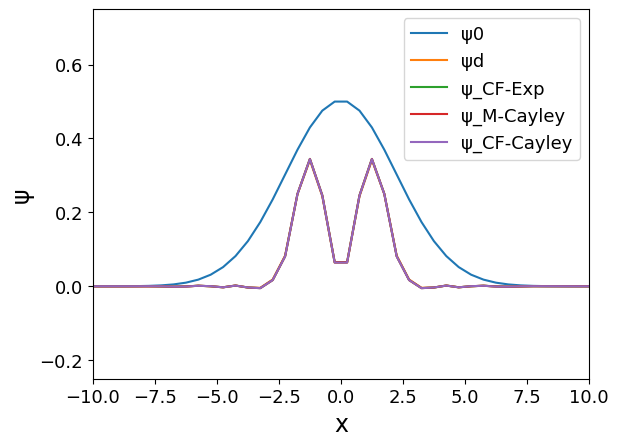

In [15]:
plt.plot(x, np.real(ψ0_origin))
plt.plot(x, np.real(ψd_cayf))
plt.plot(x, np.real(res_11['psiT']))
plt.plot(x, np.real(res_12['psiT']))
plt.plot(x, np.real(res_13['psiT']))
plt.xlim(-10,10)
plt.ylim(-0.25,0.75)
plt.xlabel('x')
plt.ylabel('ψ')
plt.legend(['ψ0', 'ψd', 'ψ_CF-Exp', 'ψ_M-Cayley', 'ψ_CF-Cayley'])
plt.savefig('SE-sol-x0-all.pdf')
plt.show()

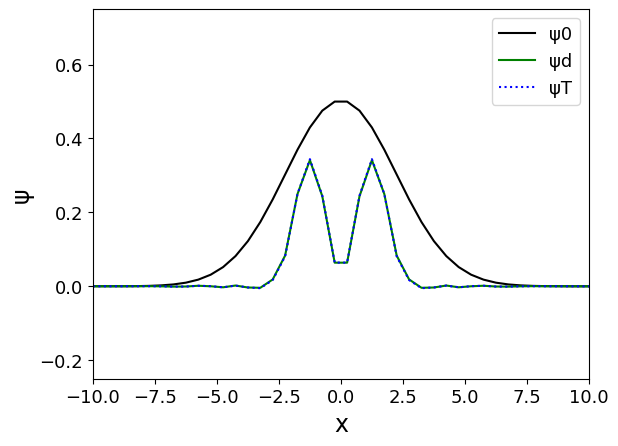

In [16]:
plt.plot(x, np.real(ψ0_origin), 'k')
plt.plot(x, np.real(ψd_cayf), 'g')
#plt.plot(x, np.real(res_11['psiT']))
#plt.plot(x, np.real(res_12['psiT']))
plt.plot(x, np.real(res_13['psiT']), ':b')
plt.xlim(-10,10)
plt.ylim(-0.25,0.75)
plt.xlabel('x')
plt.ylabel('ψ')
plt.legend(['ψ0', 'ψd', 'ψT'])
plt.savefig("SE-sol-x0-all.pdf", bbox_inches="tight")
plt.show()

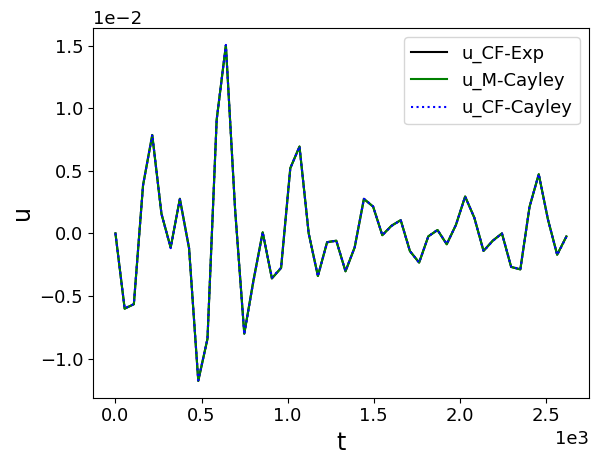

In [17]:
plt.plot(tspan, res_11['u'], 'k')
plt.plot(tspan, res_12['u'], '-g')
plt.plot(tspan, res_13['u'], ':b')
#plt.xlim(-20,20)
#plt.ylim(-1,1)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('t')
plt.ylabel('u')
plt.legend(['u_CF-Exp', 'u_M-Cayley', 'u_CF-Cayley'])
plt.savefig("SE-control-x0-all.pdf", bbox_inches="tight")
plt.show()

# Resolution of the optimal control problem: Case 2

## Exp comm-free

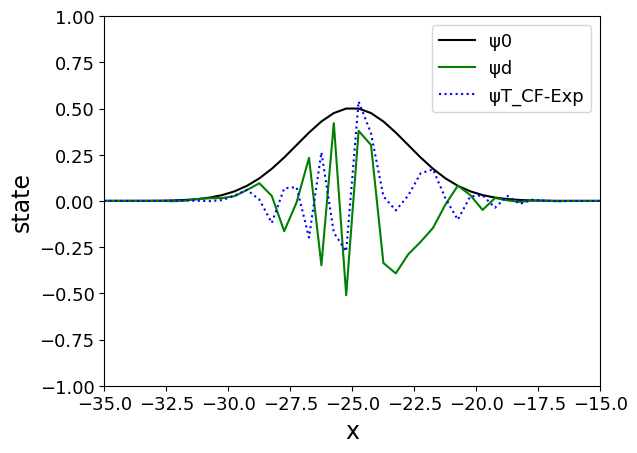

In [18]:
plt.plot(x, np.real(ψ0_shift), 'k')
plt.plot(x, np.real(ψd_exp2), 'g')
plt.plot(x, np.real(res_21['psiT']), ':b')
plt.xlim(-35,-15)
plt.ylim(-1,1)
plt.xlabel('x')
plt.ylabel('state')
plt.legend(['ψ0', 'ψd', 'ψT_CF-Exp'])
plt.savefig('SE-sol-exp-x1.pdf')
plt.show()

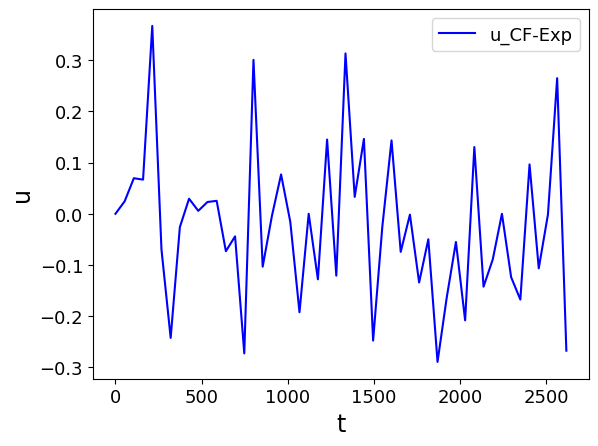

In [19]:
plt.plot(tspan, res_21['u'], 'b')
#plt.xlim(-20,20)
#plt.ylim(-1,1)
plt.xlabel('t')
plt.ylabel('u')
plt.legend(['u_CF-Exp'])
plt.savefig('ExpCF-control-x0.pdf')
plt.show()

## Cayley with commutators

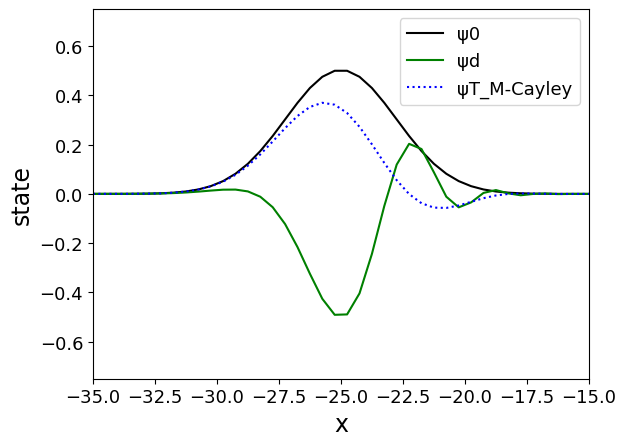

In [20]:
plt.plot(x, np.real(ψ0_shift), 'k')
plt.plot(x, np.real(ψd_cayl2), 'g')
plt.plot(x, np.real(res_22['psiT']), ':b')
plt.xlim(-35,-15)
plt.ylim(-0.75,0.75)
plt.xlabel('x')
plt.ylabel('state')
plt.legend(['ψ0', 'ψd', 'ψT_M-Cayley'])  ## 'ψ_exp',
plt.savefig('SE-sol-cayley-x1.pdf')
plt.show()

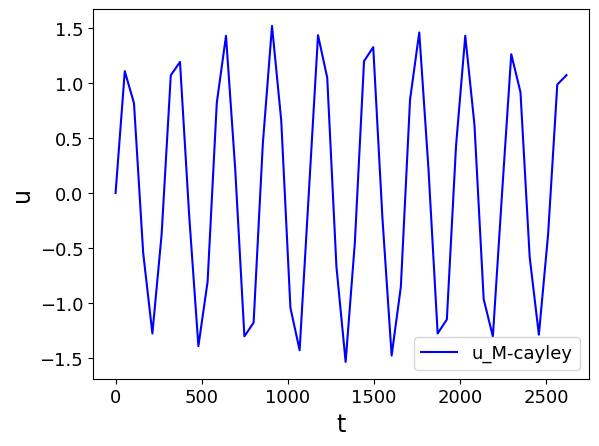

In [21]:
plt.plot(tspan, res_22['u'], 'b')
#plt.xlim(-20,20)
#plt.ylim(-1,1)
plt.xlabel('t')
plt.ylabel('u')
plt.legend(['u_M-cayley']) # 'u_exp',
plt.savefig('Cayley-control-x1.pdf')
plt.show()

## Cayley comm-free

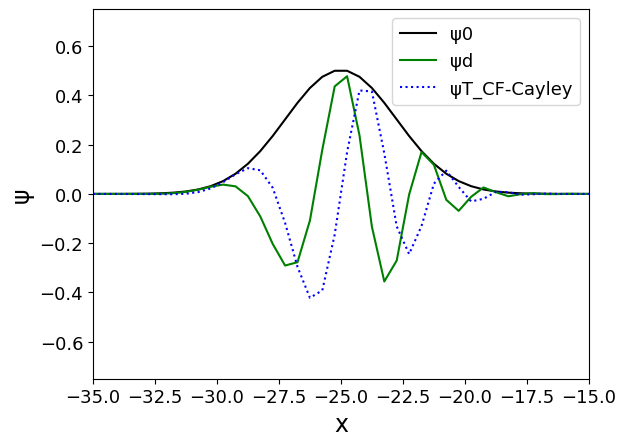

In [22]:
plt.plot(x, np.real(ψ0_shift), 'k')
plt.plot(x, np.real(ψd_cayf2), 'g')
plt.plot(x, np.real(res_23['psiT']), ':b')
plt.xlim(-35,-15)
plt.ylim(-0.75,0.75)
plt.xlabel('x')
plt.ylabel('ψ')
plt.legend(['ψ0', 'ψd', 'ψT_CF-Cayley'])  ## 'ψ_exp',
plt.savefig("SE-sol-CayleyCF-x1.pdf", bbox_inches="tight")

plt.show()

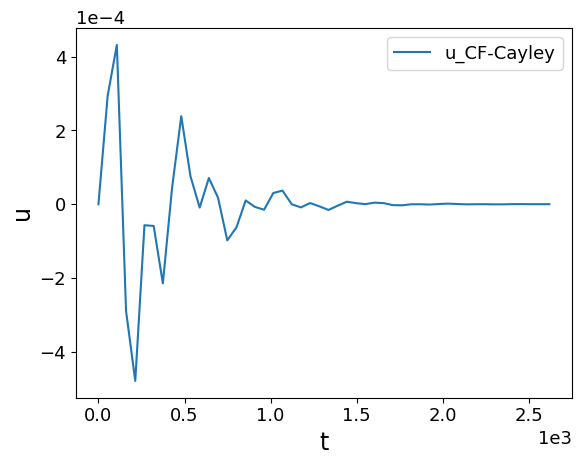

In [23]:
plt.plot(tspan, res_23['u'])
#plt.xlim(-20,20)
#plt.ylim(-1,1)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('t')
plt.ylabel('u')
plt.legend(['u_CF-Cayley']) # 'u_exp',
plt.savefig("CFC-control-x1.pdf", bbox_inches="tight")

plt.show()

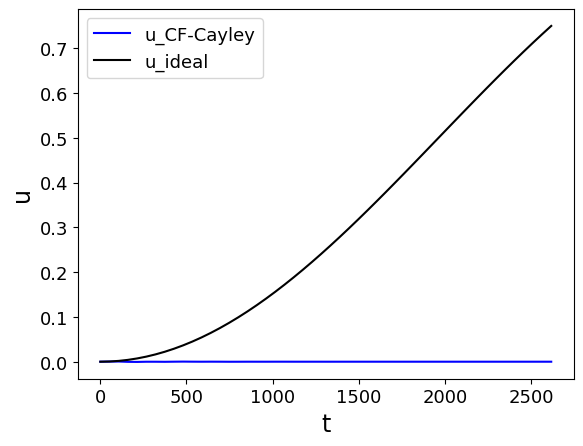

In [24]:
plt.plot(tspan, res_23['u'], 'b')
plt.plot(tspan, U, 'k')
#plt.xlim(-20,20)
#plt.ylim(-1,1)
plt.xlabel('t')
plt.ylabel('u')
plt.legend(['u_CF-Cayley', 'u_ideal']) # 'u_exp',
plt.savefig('SE-control-x1-all.pdf')
plt.show()

In [25]:
def to_row(initial_label, res):
    return {
        "Scheme"            : res['scheme'],
        "Initial state"     : initial_label,
        "Converged"         : "✓" if res['converged'] else "✗",
        "CPU time (s)"      : f"{res['runtime_sec']:.3f}",
        "# Iterations"      : res['iterations'],
        "Final fidelity"    : f"{res['final_fidelity']:.6f}",
        "Tolerance"         : tol
    }

rows = []
rows += [to_row("Gaussian ($x_0=0$)",    res_11),
         to_row("Gaussian ($x_0=0$)",    res_12),
         to_row("Gaussian ($x_0=0$)",    res_13),
         to_row("Gaussian ($x_0=-25$)",  res_21),
         to_row("Gaussian ($x_0=-25$)",  res_22),
         to_row("Gaussian ($x_0=-25$)",  res_23)]

df_lin = pd.DataFrame(rows, columns=[
    "Scheme","Initial state","Converged","CPU time (s)","# Iterations","Final fidelity","Tolerance"
])
df_lin


,Scheme,Initial state,Converged,CPU time (s),# Iterations,Final fidelity,Tolerance
0,Exp. CF 4 (Alvermann–Fehske 2011),Gaussian ($x_0=0$),✓,484.249,4,0.999981,0.00001
1,Cayley–Magnus 4 (Iserles 2001),Gaussian ($x_0=0$),✓,34.119,4,0.999981,0.00001
2,CF–Cayley 4 (Wembe 2025),Gaussian ($x_0=0$),✓,30.073,4,0.999981,0.00001
3,Exp. CF 4 (Alvermann–Fehske 2011),Gaussian ($x_0=-25$),✗,6360.219,50,0.273775,0.00001
4,Cayley–Magnus 4 (Iserles 2001),Gaussian ($x_0=-25$),✓,89.887,10,0.734326,0.00001
5,CF–Cayley 4 (Wembe 2025),Gaussian ($x_0=-25$),✓,27.609,4,0.987149,0.00001


In [26]:
print(df_lin.to_latex(index=False, escape=False,
      caption="Comparison of propagation schemes in the linear Schrödinger case (tolerance $\\varepsilon=10^{-5}$).",
      label="tab:linear-results"))


\begin{table}
\caption{Comparison of propagation schemes in the linear Schrödinger case (tolerance $\varepsilon=10^{-5}$).}
\label{tab:linear-results}
\begin{tabular}{llllrlr}
\toprule
Scheme & Initial state & Converged & CPU time (s) & # Iterations & Final fidelity & Tolerance \\
\midrule
Exp. CF 4 (Alvermann–Fehske 2011) & Gaussian ($x_0=0$) & ✓ & 484.249 & 4 & 0.999981 & 0.000010 \\
Cayley–Magnus 4 (Iserles 2001) & Gaussian ($x_0=0$) & ✓ & 34.119 & 4 & 0.999981 & 0.000010 \\
CF–Cayley 4 (Wembe 2025) & Gaussian ($x_0=0$) & ✓ & 30.073 & 4 & 0.999981 & 0.000010 \\
Exp. CF 4 (Alvermann–Fehske 2011) & Gaussian ($x_0=-25$) & ✗ & 6360.219 & 50 & 0.273775 & 0.000010 \\
Cayley–Magnus 4 (Iserles 2001) & Gaussian ($x_0=-25$) & ✓ & 89.887 & 10 & 0.734326 & 0.000010 \\
CF–Cayley 4 (Wembe 2025) & Gaussian ($x_0=-25$) & ✓ & 27.609 & 4 & 0.987149 & 0.000010 \\
\bottomrule
\end{tabular}
\end{table}

